# Basics of Matplotlib

***Before we start***, if you want to learn more about matplotlib or have questions that are not answered in these notes, check out the [official matplotlib tutorials](https://matplotlib.org/stable/tutorials/index.html#tutorials) and some [matplotlib plot examples](https://matplotlib.org/stable/gallery/index.html).

## Plotting in Matplotlib with Axes
For the first section of these notes, we're going to work with a dataset on various species that have been recorded between 1977 and 2002. The dataset includes a record id, the month, day, and year when the specimen was recorded, a plot id and species id, and the sex, hindfoot length, and weight of the specimen.

We can use matplotlib to explore the data by creating different visualizations of various aspects of the data. This allows us to examine trends and come to conclusions about the data.

In [1]:
# Importing packages!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Let's read in the species dataset using pandas and take a look at the data.

In [2]:
species_df = pd.read_csv('surveys.csv')
species_df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
...,...,...,...,...,...,...,...,...,...
35544,35545,12,31,2002,15,AH,NaN,NaN,NaN
35545,35546,12,31,2002,15,AH,NaN,NaN,NaN
35546,35547,12,31,2002,10,RM,F,15.0,14.0
35547,35548,12,31,2002,7,DO,M,36.0,51.0


### `plt` vs Axes

In the past, we have plotted with matplotlib using the `plt` command. Using `plt` allowed us to easier make simple plots, like the one below:

Text(0.5, 1.0, 'Hindfoot length vs Weight in Various Species')

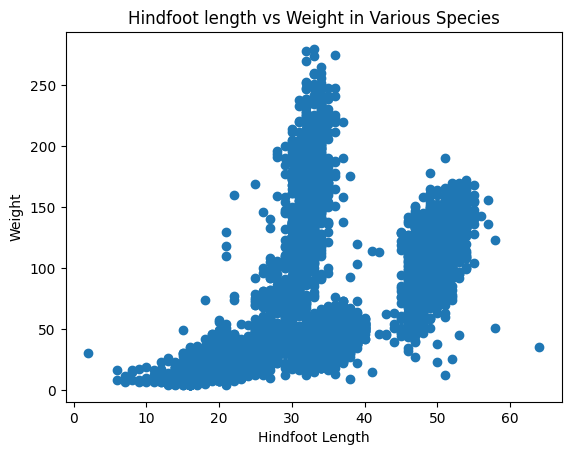

In [ ]:
# Creates a simple scatterplot
plt.scatter(species_df['hindfoot_length'], species_df['weight'])

# Plots axes labels and a title
plt.xlabel("Hindfoot Length")
plt.ylabel("Weight")
plt.title("Hindfoot length vs Weight in Various Species")

However, we are now pivoting towards using matplotlib **axes** for plotting. Axes enable us to create more complex plots, as they can be used to make subplots.

Below is the same plot as above, but created using axes instead of `plt`:

Text(0.5, 1.0, 'Hindfoot length vs Weight in Various Species')

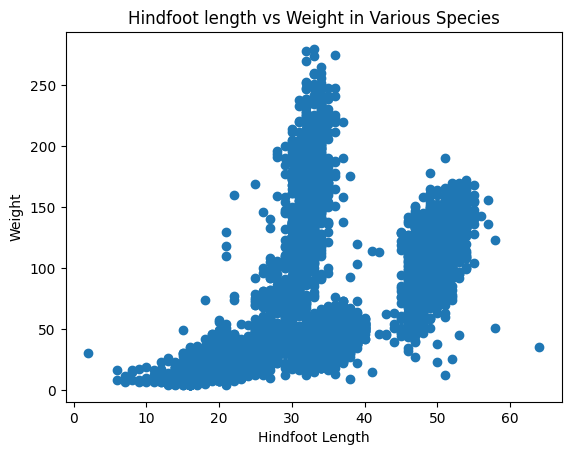

In [ ]:
# Creates a figure and an axis
fig,ax1 = plt.subplots()

# Creates a scatter plot
ax1.scatter(species_df['hindfoot_length'], species_df['weight'])

# Plots axes labels and a title
ax1.set_xlabel("Hindfoot Length")
ax1.set_ylabel("Weight")
ax1.set_title("Hindfoot length vs Weight in Various Species")

There are a few noticiable differences between the `plt` and axes code:
1. To create and use an axis, you must include the code `fig, axis = plt.subplots()`. The `fig` handle allows you to make changes to the entire plot, whereas the `axis` handle allows you to make changes to a specific subplot. Later on, we'll show how to create multiple axes for one figure. 
2. In the axis code, `ax1` now replaces `plt` in the plotting functions.
3. The functions for settings axes labels and making a title differ.

## Creating a more complex scatterplot

Let's use axes to create a more complex scatterplot! We'll examine the relationship between hindfoot length and weight in the 'DS' and 'SO' species in this plot.

The following arguments can be used to alter different aspects of the plot in the `scatter` function:
- `s` changes marker size
- `c` changes marker color
- `label` adds a label for the legend
- `facecolors='none'` creates hollow points
- `edgecolors=...` changes edge color

Additionally, `set_aspect()` changes the aspect ratio of the plot.

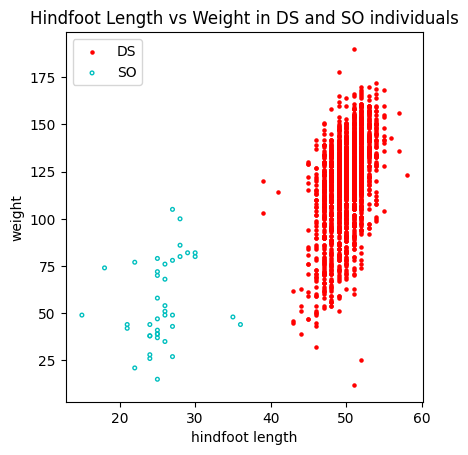

In [5]:
# Creates a figure and an axis
fig,ax2 = plt.subplots()

# Subsets the DS and SO species
ds_df = species_df[species_df['species_id'] == 'DS']
so_df = species_df[species_df['species_id'] == 'SO']

# Creates scatterplots for each species
ax2.scatter(ds_df['hindfoot_length'], ds_df['weight'], s=5, c='r', label='DS')
ax2.scatter(so_df['hindfoot_length'], so_df['weight'], s=7, facecolors='none', edgecolors='c', label='SO')

# Sets aspect and labels plot
ax2.set_aspect(.25)
ax2.set_xlabel('hindfoot length')
ax2.set_ylabel('weight')
ax2.set_title('Hindfoot Length vs Weight in DS and SO individuals')
ax2.legend()

It looks like there's a positive correlation between longer hindfoot length and higher weight in the DS species, but maybe not in the SO species. The DS species also has longer hindfeet, and often weigh more than the SO species.

## Creating multiple plots

Multiple plots can be created by creating multiple axes in one figure. In the `plt.subplots()` function, we can specify the number of subplots we want. The first argument is the number of rows, while the second argument is the number of columns. In our code, we assign the first subplot to ax3a, and the second subplot to ax3b. 

We can recreate our plot from above, with the different species in seperate subplots.

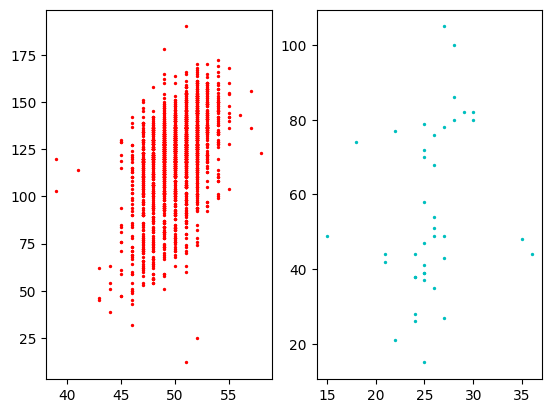

In [ ]:
# Creates the figure and axes
fig, (ax3a, ax3b) = plt.subplots(1,2)

# Creates the scatterplots
ax3a.scatter(ds_df['hindfoot_length'], ds_df['weight'], s=2, c='r')
ax3b.scatter(so_df['hindfoot_length'], so_df['weight'], s = 2, c = 'c')

## Creating a histogram

Histograms can be created in matplotlib using the `hist()` function. In the `hist()` function, `bins` changes the bins size and range for the plot and `histtype='step'` makes an unfilled histogram.

Let's examine the hindfoot length observations and data between the DS and SO species.

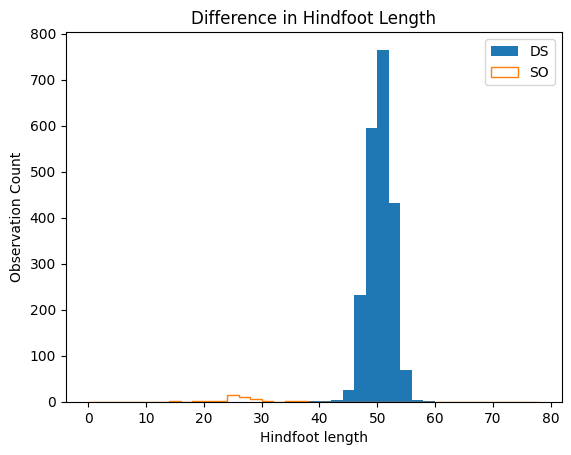

In [8]:
# Creates the figure and axis
fig,ax4 = plt.subplots()

# Creates the species histograms
ax4.hist(ds_df['hindfoot_length'], bins=range(0,80,2), label = 'DS')
ax4.hist(so_df['hindfoot_length'], bins=range(0,80,2), histtype='step', label = 'SO')

# Creates a legend and labels for the plot
ax4.set_title('Difference in Hindfoot Length')
ax4.set_xlabel("Hindfoot length")
ax4.set_ylabel("Observation Count")
ax4.legend()

Overall, the DS species seems to have longer hindfoot length. There are also significantly more observations for that species! The data would possibly be more informative if there were more observations of the SO species.

## Plotting lines
I wonder why there's so few SO observations compared to DS observations? Let's examine that by plotting the count of the SO species over time. We'll use the `plot()` function to plot a line, then the `scatter()` function to add points to the line.

Text(0, 0.5, 'Number of observations')

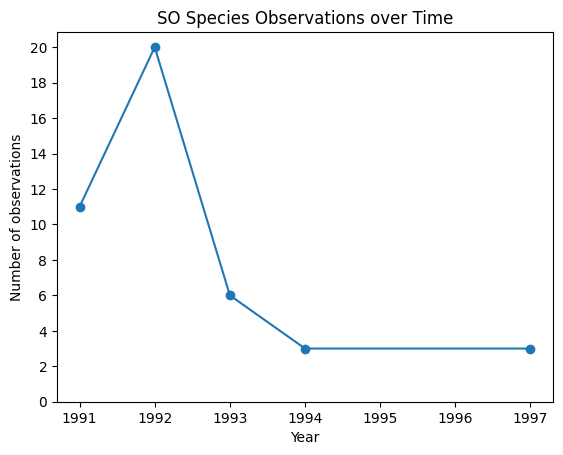

In [16]:
# Creates the figure and axis
fig,ax5 = plt.subplots()

# Groups the data and resets the index
grouped_data = so_df.groupby('year').agg(so_count = ('species_id', 'count'))
year_data = grouped_data.reset_index()

# Plots the data
ax5.plot(year_data['year'], year_data['so_count'])
ax5.scatter(year_data['year'], year_data['so_count'])

# Sets the tick numbers for the y-axis
ax5.set_yticks(range(0, 22, 2))

# Creates labels for the plot
ax5.set_title("SO Species Observations over Time")
ax5.set_xlabel("Year")
ax5.set_ylabel("Number of observations")

It looks like the observations of SO species decreased over time. This could be due to less study of the species, a decrease in population due to environmental factors or threats, or various other reasons. 